# PRA Runtime Productization: All Mechanisms

This is the Paper 4.5 systems notebook. It follows selected memory from a stable reference URI to
physical native K/V, cache residency, measurement, typed resource disclosure, safe execution, and
a thin serving-engine handoff.

The notebook is deliberately offline. A tiny random Llama exercises the real Hugging Face/PRA
adapter, while deterministic in-memory resources exercise lifecycle and safety boundaries. The
generated language is not meaningful; tensor parity, state transitions, accounting, and API
behavior are the objects under test.

## How this differs from the Paper 2 model-family demo

The two notebooks are complementary, not replacements.

| Question | `pra_hf_model_families.ipynb` (Paper 2) | This notebook (Paper 4.5) |
|---|---|---|
| Primary concern | Does PRA attach to supported HF model families? | Does sparse selection become a controllable physical runtime? |
| Models exercised | Qwen 3, Llama, and Gemma 3 sessions | One offline tiny Llama plus checked-in pretrained cross-model gate summaries |
| References | Direct text references through `PRAForCausalLM` | Direct references plus authenticated external cold/warm/hot resources |
| K/V internals | Model-level routing and generation statistics | Exact intervals, budgets, GQA/MQA shape, layouts, transfer and temporary bytes |
| Runtime state | Per-model examples | Versioned config, sessions, LRU reuse, eviction, and stage profiler |
| Tools | Outside scope | Typed discovery, capability-graph disclosure, and independent execution authority |
| Serving | Ordinary HF generation | Capability gates and scheduler-unaware vLLM handoff |

Use the Paper 2 notebook to validate a model family. Use this notebook to understand and reproduce
the unified SDK and the boundary between logical selection and physical execution.

In [1]:
from pathlib import Path
import csv
import json
import platform
import sys
import tempfile
from types import SimpleNamespace

DEMO_DIR = Path.cwd().resolve()
PROJECT_ROOT = DEMO_DIR.parent
SOURCE_ROOT = PROJECT_ROOT / "src"
sys.path.insert(0, str(SOURCE_ROOT))

import torch
import transformers
from transformers import LlamaConfig, LlamaForCausalLM

from pra_hf import (
    AgentConfig,
    AdaptiveContextRuntime,
    DeepSeekHarnessPRAAdapter,
    InMemorySessionService,
    AuthContext,
    CapabilityEncodingPolicy,
    CapabilitySDK,
    ContextPolicy,
    CursorAction,
    DiscoveryRequest,
    EncodingContext,
    ExecutionAuthorization,
    EngineProfileRegistry,
    ExternalMemoryManager,
    HotMemoryHandle,
    KVInterval,
    KVMaterializer,
    MaterializationPlan,
    NativeEncoding,
    NativeKV,
    NativeMaterializationMode,
    PackedNativeKVStore,
    PersistentResourceIndex,
    PRAConfig,
    PRAAgent,
    PRAAgentConfig,
    PRAAgentPluginConfig,
    PRAEngineCapabilities,
    PRAEngineResult,
    PRAGateway,
    PRAWireRequest,
    PRAWireResource,
    PRARuntime,
    PRARuntimeConfig,
    ProgressiveContextRuntime,
    ProfileBenchmarkRegistry,
    LargeRecordSearchPolicy,
    PiCodingAgentPRAAdapter,
    ResolverRegistry,
    ResourceDiscoveryEngine,
    ResourceStat,
    RecordCapabilities,
    RecordScope,
    RecordType,
    RecordViewName,
    HistoryMode,
    RuntimeKVCache,
    RuntimeKVCacheKey,
    RuntimeProfiler,
    SafeToolExecutor,
    SelectedKVGather,
    Skill,
    Tool,
    Toolset,
    TaskOperation,
    TypeContextPolicy,
    VLLMThinBackend,
    default_toolset,
    runtime_capabilities,
)
from pra_hf.agent_disclosure import ToolCapabilityGraph, disclosure_policy_for_profile
from pra_hf.runtime_benchmark import run_runtime_microbenchmark
from data.agent_workflows import realistic_tool_catalog, workflow_executor, workflow_tasks

torch.manual_seed(7)
torch.set_grad_enabled(False)

print("Using the repository source package")
print({
    "python": platform.python_version(),
    "torch": torch.__version__,
    "transformers": transformers.__version__,
})

Using the repository source package
{'python': '3.10.11', 'torch': '2.12.1+cu126', 'transformers': '4.55.4'}


## 1. Capability discovery is a claim boundary

The runtime reports optional systems without importing them. Availability is not performance:
`torch.compile`, Triton, vLLM, SGLang, TensorRT-LLM, and MLX remain unsupported or contract-only
until the corresponding path is actually executed and measured on the current host.

In [2]:
capabilities = runtime_capabilities()
capabilities

{'python': '3.10.11',
 'platform': 'Windows-10-10.0.19045-SP0',
 'torch': '2.12.1+cu126',
 'cuda_available': True,
 'cuda_version': '12.6',
 'cuda_device': 'NVIDIA GeForce GTX 950M',
 'cuda_capability': [5, 0],
 'torch_compile_api': True,
 'triton_installed': False,
 'vllm_installed': False,
 'sglang_installed': False,
 'tensorrt_llm_installed': False,
 'mlx_installed': False}

## 1.1 Measured HF family compatibility

The executable cells below remain offline and use a tiny random Llama fixture, but the checked-in
Paper 4.5 gate was also run on pinned pretrained Qwen, Llama, and Gemma checkpoints. Qwen is the
primary semantic reference. The Llama row uses an explicitly named public weight mirror because
the official Meta repository was inaccessible. Gemma is a partial topology result: disabled
behavior, native MQA shape, source positions, and decode lifetime pass, while global-layer-only
memory does not reproduce a visible prefix processed by unchanged local sliding layers.

The four semantic conditions keep record selection, token width, and consumer-layer coverage
visible as separate axes. A sparse layer profile is therefore not treated as equivalent merely
because it selected the correct record.

In [3]:
cross_model_dir = PROJECT_ROOT / "docs" / "papers" / "shared" / "results" / "paper4_5_runtime"

with (cross_model_dir / "hf_cross_model_manifest.csv").open(encoding="utf-8") as stream:
    cross_model_manifest = list(csv.DictReader(stream))
with (cross_model_dir / "hf_cross_model_native_parity.csv").open(encoding="utf-8") as stream:
    cross_model_parity = list(csv.DictReader(stream))

[
    {
        "model": row["model"],
        "status": row["status"],
        "full_native_max_logit_error": float(row["full_native_max_logit_error"]),
        "full_native_top_token_equal": row["full_native_top_token_equal"],
        "topology_coverage": row["topology_coverage"],
    }
    for row in cross_model_parity
]

[{'model': 'qwen',
  'status': 'passed',
  'full_native_max_logit_error': 0.036376953125,
  'full_native_top_token_equal': 'True',
  'topology_coverage': 'all_decoder_layers'},
 {'model': 'llama',
  'status': 'passed',
  'full_native_max_logit_error': 0.0234375,
  'full_native_top_token_equal': 'True',
  'topology_coverage': 'all_decoder_layers'},
 {'model': 'gemma',
  'status': 'partial_topology',
  'full_native_max_logit_error': 9.541015625,
  'full_native_top_token_equal': 'True',
  'topology_coverage': 'global_layers_only_local_sliding_layers_native'}]

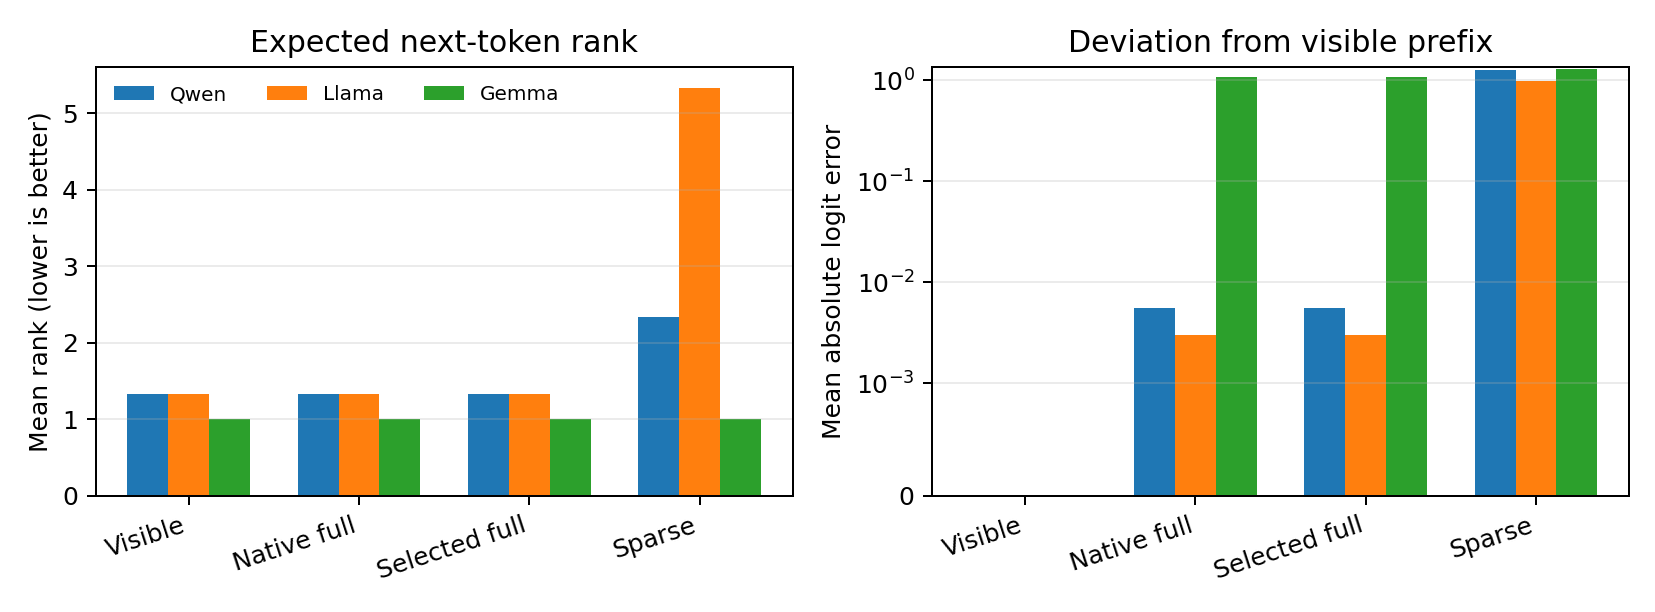

In [4]:
from IPython.display import Image, display

display(Image(filename=str(cross_model_dir / "hf_cross_model_semantic_gate.png")))

## 2. Separate PRA semantics from systems policy

`PRAConfig` controls routing and memory consumption semantics. `PRARuntimeConfig` layers physical
choices over it: backend, compilation mode, K/V layout, page size, cache limits, prefetch policy,
and profiler behavior. A runtime optimization is valid only when changing these systems fields
preserves model semantics.

The config artifact contains no credentials or model weights.

In [5]:
runtime_config = PRARuntimeConfig(
    pra=PRAConfig(
        routing_layer=-1,
        consumption_layers=(-1,),
        chunk_tokens=8,
        selected_fraction=0.5,
        max_direct_context=32,
        native_operation_limit=64,
        max_materialized_tokens=16,
        context_safety_reserve_tokens=0,
        encoding_block_tokens=32,
    ),
    backend="huggingface",
    compilation="eager",
    kv_layout="layer_major",
    page_tokens=4,
    cache_max_bytes=1 << 20,
    cache_max_entries=8,
)

with tempfile.TemporaryDirectory() as directory:
    config_path = runtime_config.save_pretrained(directory)
    restored_config = PRARuntimeConfig.from_pretrained(directory)
    config_artifact = json.loads(config_path.read_text(encoding="utf-8"))

{
    "round_trip_equal": restored_config == runtime_config,
    "schema_version": config_artifact["schema_version"],
    "systems_policy": {
        key: config_artifact[key]
        for key in ("backend", "compilation", "kv_layout", "page_tokens", "cache_max_bytes")
    },
}

{'round_trip_equal': True,
 'schema_version': 1,
 'systems_policy': {'backend': 'huggingface',
  'compilation': 'eager',
  'kv_layout': 'layer_major',
  'page_tokens': 4,
  'cache_max_bytes': 1048576}}

## 3. One facade over the Paper 2 model API

`PRARuntime.from_model` wraps an existing HF model through `PRAForCausalLM`. In deployment,
`from_pretrained` performs the equivalent model and tokenizer load. Stable URIs connect references,
routing traces, caches, authorization, and physical K/V without using filenames as identity.

The tiny tokenizer is only an offline fixture. The model path itself is the real Llama adapter,
including grouped-query attention with fewer physical K/V heads than query heads.

In [6]:
class TinyTokenizer:
    all_special_ids = (0, 1)

    def __call__(self, text, return_tensors="pt", add_special_tokens=False, **_kwargs):
        values = [2 + (ord(char) % 61) for char in text]
        if add_special_tokens:
            values.insert(0, 1)
        return SimpleNamespace(input_ids=torch.tensor([values], dtype=torch.long))

    def decode(self, token_ids, skip_special_tokens=True):
        return " ".join(str(int(value)) for value in token_ids)

    def convert_ids_to_tokens(self, token_ids):
        return [str(int(value)) for value in token_ids]


def build_tiny_runtime(config, **components):
    model_config = LlamaConfig(
        vocab_size=67,
        hidden_size=32,
        intermediate_size=64,
        num_hidden_layers=2,
        num_attention_heads=4,
        num_key_value_heads=2,
        max_position_embeddings=64,
        bos_token_id=1,
        eos_token_id=66,
        pad_token_id=0,
    )
    model_config._attn_implementation = "eager"
    model = LlamaForCausalLM(model_config).eval()
    return PRARuntime.from_model(
        model, TinyTokenizer(), runtime_config=config, **components
    )


runtime = build_tiny_runtime(runtime_config)
handle = runtime.add_reference(
    "memory://demo/facts",
    text="Paris is the capital of France.",
)
generation = runtime.generate(
    "Question: capital of France? Answer:",
    max_new_tokens=1,
    return_details=True,
)
{
    "reference_uri": handle.uri,
    "generated_token_fixture": generation.text,
    "selected": generation.stats["selected"],
    "materialized_kv_tokens": generation.stats["materialized_kv_tokens"],
    "backend": runtime.inspect()["backend"],
}

{'reference_uri': 'memory://demo/facts',
 'generated_token_fixture': '65',
 'selected': [{'reference_uri': 'memory://demo/facts',
   'reference_score': -0.08640310168266296,
   'chunk_id': 'memory://demo/facts#chunk=16:24',
   'chunk_score': -0.08640310168266296,
   'layer_id': 1,
   'token_start': 16,
   'token_end': 24,
   'logical_start': 16,
   'logical_end': 24,
   'selected_token_count': 8,
   'reference_rank': 1,
   'rank_within_reference': 1,
   'winning_gist_index': 0,
   'winning_gist_score': -0.08640310168266296,
   'gist_count': 1,
   'winning_reference_gist_index': None,
   'winning_reference_gist_score': None,
   'reference_gist_count': 0,
   'metadata': {'selection_policy': 'selected_fraction'}},
  {'reference_uri': 'memory://demo/facts',
   'reference_score': -0.08640310168266296,
   'chunk_id': 'memory://demo/facts#chunk=8:16',
   'chunk_score': -0.1728655993938446,
   'layer_id': 1,
   'token_start': 8,
   'token_end': 16,
   'logical_start': 8,
   'logical_end': 16,


## 4. Authenticated external memory: cold, warm, and hot

Direct text is convenient, but production memory often starts as a URI. The external-memory
manager keeps three distinct states:

1. **Cold:** authorized descriptor and cheap external gist; source bytes are not encoded.
2. **Warm:** source is fetched and encoded into model-specific native memory.
3. **Hot:** the selected native K/V is materialized for immediate use.

Authorization is rechecked at the resolver boundary. Credentials remain opaque and are absent from
session snapshots and metrics. The example resolver is in-memory so it has no external side effect.

In [7]:
class NotebookMemoryResolver:
    name = "mem"

    def __init__(self):
        self.documents = {}
        self.fetches = 0

    def put(self, uri, text, version="v1"):
        self.documents[uri] = {"text": text, "version": version}

    def _authorized(self, uri, auth_context):
        if uri not in auth_context.authorization_scopes:
            raise PermissionError(f"Resource not authorized: {uri}")
        auth_context.credentials_for(self.name, uri)
        return self.documents[uri]

    async def stat(self, uri, auth_context, session):
        document = self._authorized(uri, auth_context)
        payload = document["text"].encode()
        return ResourceStat(
            uri=uri,
            resolver=self.name,
            version=document["version"],
            size_bytes=len(payload),
            title=document["text"],
        )

    async def fetch(self, uri, auth_context, session, byte_range=None):
        document = self._authorized(uri, auth_context)
        self.fetches += 1
        payload = document["text"].encode()
        return payload if byte_range is None else payload[slice(*byte_range)]

    async def external_gist(self, uri, metadata, auth_context, session):
        return metadata.title or uri


def notebook_encoder(source, metadata, context):
    tokens = tuple(source.decode().split())
    return NativeEncoding(
        uri=metadata.uri,
        source_version=metadata.version,
        model_fingerprint=context.model_fingerprint,
        tokenizer_fingerprint=context.tokenizer_fingerprint,
        config_fingerprint=context.config_fingerprint,
        token_count=len(tokens),
        byte_count=len(source),
        pra_gists=(" ".join(tokens[:3]),),
        logical_offsets=((0, len(tokens)),),
        payload=tokens,
    )


def notebook_materializer(encoding, selected_token_ids):
    tokens = encoding.payload
    if selected_token_ids is not None:
        tokens = tuple(tokens[index] for index in selected_token_ids)
    return HotMemoryHandle(
        uri=encoding.uri,
        source_version=encoding.source_version,
        selected_token_count=len(tokens),
        byte_count=sum(len(token.encode()) for token in tokens),
        payload=tokens,
    )


resolver = NotebookMemoryResolver()
registry = ResolverRegistry()
registry.register("mem", resolver)
manager = ExternalMemoryManager(
    encoding_context=EncodingContext(
        model_fingerprint="tiny-llama",
        tokenizer_fingerprint="tiny-tokenizer",
        encoding_config={"block_tokens": 32, "position": "rope"},
    ),
    encoder=notebook_encoder,
    materializer=notebook_materializer,
    resolvers=registry,
)

In [8]:
uri = "mem://documents/alpha"
resolver.put(uri, "alpha evidence connects beta")
auth = AuthContext(
    tenant_id="demo-tenant",
    user_id="demo-user",
    session_id="demo-session",
    authorization_scopes=frozenset({uri}),
    credential_provider=lambda _resolver, _uri: "opaque-demo-token",
)
memory_runtime = PRARuntime(
    config=runtime.config,
    backend=runtime.backend,
    external_memory=manager,
)
session = memory_runtime.open_session(
    session_id="demo-session",
    user_id="demo-user",
    tenant_id="demo-tenant",
    auth_context=auth,
)
record = await memory_runtime.add_external_reference(session, uri=uri, encoding_mode="lazy")
cold_tier = record.tier
candidates = await manager.route_candidates(session, "alpha evidence")
await manager.admit(session, candidates, max_admitted=1)
warm_tier = record.tier
first_hot = await manager.ensure_hot(session, uri, selected_token_ids=(0, 2))
hot_tier = record.tier
second_hot = await manager.ensure_hot(session, uri)
third_hot = await manager.ensure_hot(session, uri)

safe_state = memory_runtime.inspect()
{
    "tier_transitions": [cold_tier, warm_tier, hot_tier],
    "selected_hot_payload": first_hot.payload,
    "reused_full_hot_handle": second_hot == third_hot,
    "resolver_fetches": resolver.fetches,
    "lifecycle_metrics": safe_state["external_memory"],
    "session_snapshot": safe_state["sessions"][0],
    "credential_leaked": "opaque-demo-token" in json.dumps(safe_state),
}

{'tier_transitions': ['cold', 'warm', 'hot'],
 'selected_hot_payload': ('alpha', 'connects'),
 'reused_full_hot_handle': True,
 'resolver_fetches': 1,
 'lifecycle_metrics': {'candidate_resources': 1,
  'admitted_resources': 1,
  'descriptor_hits': 5,
  'descriptor_misses': 1,
  'source_hits': 0,
  'source_misses': 1,
  'native_hits': 3,
  'native_misses': 1,
  'hot_hits': 1,
  'hot_misses': 2,
  'fetched_bytes': 28,
  'newly_encoded_tokens': 4,
  'external_retrieval_seconds': 3.809994086623192e-05,
  'stat_seconds': 9.8800053820014e-05,
  'fetch_seconds': 4.400033503770828e-06,
  'native_encode_seconds': 4.820013418793678e-05,
  'materialization_seconds': 5.349982529878616e-05,
  'descriptor_hit_rate': 0.8333333333333334,
  'source_hit_rate': 0.0,
  'native_hit_rate': 0.75,
  'hot_hit_rate': 0.3333333333333333},
 'session_snapshot': {'session_id': 'demo-session',
  'user_id': 'demo-user',
  'tenant_id': 'demo-tenant',
  'cache_scope': 'session',
  'resource_uris': ['mem://documents/alp

## 5. Exact interval planning before physical K/V work

Routing produces logical selections. `MaterializationPlan` turns them into stable half-open
`[start, end)` intervals grouped by URI and layer. Overlaps are merged before the global token
budget is enforced, preventing repeated K/V from consuming capacity twice.

In [9]:
plan = MaterializationPlan.build(
    [
        KVInterval("memory://demo/a", 0, 0, 8),
        KVInterval("memory://demo/a", 0, 4, 12),
        KVInterval("memory://demo/b", 0, 0, 8),
    ],
    max_tokens=16,
)
{
    "requested_tokens": plan.requested_tokens,
    "unique_tokens_after_merge_and_budget": plan.unique_tokens,
    "dropped_tokens": plan.dropped_tokens,
    "physical_intervals": plan.intervals,
}

{'requested_tokens': 24,
 'unique_tokens_after_merge_and_budget': 16,
 'dropped_tokens': 8,
 'physical_intervals': (KVInterval(uri='memory://demo/a', layer_id=0, start=0, end=12),
  KVInterval(uri='memory://demo/b', layer_id=0, start=0, end=4))}

## 6. Native K/V shape and grouped-query attention

Warm K/V is stored as `[batch, physical_kv_heads, tokens, head_dim]`. It is not expanded to the
larger number of query heads. For GQA and MQA, preserving physical K/V heads is essential to the
memory claim; head expansion belongs at attention consumption, not in persistent memory.

In [10]:
def native_kv(tokens, offset=0.0):
    key = torch.arange(1 * 2 * tokens * 4, dtype=torch.float32).reshape(1, 2, tokens, 4)
    key = key + offset
    return NativeKV(key, key + 1000)


sources = {
    ("memory://demo/a", 0): native_kv(12),
    ("memory://demo/b", 0): native_kv(8, 100),
}
materialized = KVMaterializer().materialize(sources, plan)
{
    "source_shape": tuple(sources[("memory://demo/a", 0)].key.shape),
    "packed_shape": tuple(materialized.layers[0].key.shape),
    "logical_tokens": materialized.logical_tokens,
    "physical_bytes": materialized.physical_bytes,
    "transfer_bytes": materialized.transfer_bytes,
    "temporary_bytes": materialized.temporary_bytes,
}

{'source_shape': (1, 2, 12, 4),
 'packed_shape': (1, 2, 16, 4),
 'logical_tokens': 16,
 'physical_bytes': 1024,
 'transfer_bytes': 0,
 'temporary_bytes': 1024}

## 7. Four physical layouts, one logical result

The store can be ordered layer-major, reference-major, chunk-major, or block-major. A placement
index remaps logical URI/layer/page coordinates into contiguous physical ranges. Layout is a
systems choice only: every layout must reconstruct identical per-layer K/V before attention.

In [11]:
layout_rows = []
reference = KVMaterializer().materialize(sources, plan)
for layout in ("layer_major", "reference_major", "chunk_major", "block_major"):
    store = PackedNativeKVStore(sources, layout=layout, page_tokens=4)
    restored = KVMaterializer(layout=layout).materialize(store, plan)
    parity = all(
        torch.equal(restored.layers[layer].key, reference.layers[layer].key)
        and torch.equal(restored.layers[layer].value, reference.layers[layer].value)
        for layer in reference.layers
    )
    layout_rows.append({
        "layout": layout,
        "parity": parity,
        "store_bytes": store.nbytes,
        "placement_index_bytes": store.index_bytes,
        "placements": len(store.placements),
    })
layout_rows

[{'layout': 'layer_major',
  'parity': True,
  'store_bytes': 1280,
  'placement_index_bytes': 315,
  'placements': 5},
 {'layout': 'reference_major',
  'parity': True,
  'store_bytes': 1280,
  'placement_index_bytes': 315,
  'placements': 5},
 {'layout': 'chunk_major',
  'parity': True,
  'store_bytes': 1280,
  'placement_index_bytes': 315,
  'placements': 5},
 {'layout': 'block_major',
  'parity': True,
  'store_bytes': 1280,
  'placement_index_bytes': 315,
  'placements': 5}]

## 8. Portable eager selected-token gather

`SelectedKVGather` gathers token positions from both K and V along dimension 2. The eager path is
the correctness baseline. A compiled wrapper is a separate capability gate: failure to compile is
reported, never relabeled as eager performance.

In [12]:
indices = torch.tensor([0, 3, 7, 11], dtype=torch.long)
gather = SelectedKVGather("eager")
gathered = gather(sources[("memory://demo/a", 0)], indices)
{
    "gather_state": gather.inspect(),
    "indices": indices.tolist(),
    "output_shape": tuple(gathered.key.shape),
    "exact_key_parity": torch.equal(
        gathered.key,
        sources[("memory://demo/a", 0)].key.index_select(2, indices),
    ),
}

{'gather_state': {'mode': 'eager',
  'compiled_wrapper_created': False,
  'compile_error': None},
 'indices': [0, 3, 7, 11],
 'output_shape': (1, 2, 4, 4),
 'exact_key_parity': True}

## 9. Byte-bounded hot-cache behavior

The runtime LRU limits both bytes and entries. It reports loaded and reused bytes separately, so a
high hit rate cannot conceal reload amplification or an oversized resident set.

In [13]:
cache = RuntimeKVCache(max_bytes=10, max_entries=3)
cache.put("reference-a", "A", nbytes=6)
first_reuse = cache.get("reference-a")
cache.put("reference-b", "B", nbytes=6)  # evicts A to restore the byte budget
evicted_lookup = cache.get("reference-a")
{
    "first_reuse": first_reuse,
    "evicted_lookup": evicted_lookup,
    "accounting": cache.snapshot(),
}

{'first_reuse': 'A',
 'evicted_lookup': None,
 'accounting': {'hits': 1,
  'misses': 1,
  'evictions': 1,
  'bytes_loaded': 12,
  'bytes_reused': 6,
  'entries': 1,
  'resident_bytes': 6,
  'hit_rate': 0.5,
  'reload_amplification': 2.0,
  'tenant_resident_bytes': {}}}

## 10. Stage-level profiling and physical accounting

The profiler records stage latency, input/output bytes, metadata, and peak CUDA allocation. CUDA
timings synchronize only around explicitly profiled regions. Routing quality and runtime costs stay
in separate records.

In [14]:
profiler = RuntimeProfiler(device="cpu")
with profiler.stage(
    "selected_kv_materialization",
    input_bytes=sum(memory.nbytes for memory in sources.values()),
    metadata={"layout": "layer_major", "selected_tokens": plan.unique_tokens},
) as accounting:
    profiled_materialized = KVMaterializer().materialize(sources, plan)
    accounting["output_bytes"] = profiled_materialized.physical_bytes

profiler.snapshot()

{'device': 'cpu',
 'total_seconds': 0.000646200031042099,
 'events': [{'name': 'selected_kv_materialization',
   'seconds': 0.000646200031042099,
   'input_bytes': 1280,
   'output_bytes': 1024,
   'peak_device_bytes': 0,
   'metadata': {'layout': 'layer_major', 'selected_tokens': 16}}]}

## 11. Structured mechanism benchmark

This small run exercises indexed gather, interval packing, physical layouts, hierarchy rows where
available, and cache accounting. It is a mechanism benchmark, not end-to-end TTFT. The paper uses
larger repeated runs and stores every sample as JSON/CSV before plotting.

In [15]:
benchmark = run_runtime_microbenchmark(
    device="cpu",
    candidate_tokens=256,
    selected_tokens=32,
    batches=(1, 2),
    kv_heads=2,
    head_dim=16,
    warmups=1,
    repeats=2,
    include_compile=False,
)
[
    {
        "study": row["study"],
        "mode": row["mode"],
        "batch": row["batch"],
        "status": row["status"],
        "median_ms": (
            round(row["median_seconds"] * 1000, 4)
            if row["median_seconds"] is not None
            else None
        ),
        "parity": row["parity"],
        "error": row["error"],
    }
    for row in benchmark["summary"]
]

[{'study': 'indexed_gather',
  'mode': 'eager_warm',
  'batch': 1,
  'status': 'measured',
  'median_ms': 0.1162,
  'parity': True,
  'error': None},
 {'study': 'indexed_gather',
  'mode': 'eager_warm',
  'batch': 2,
  'status': 'measured',
  'median_ms': 0.1389,
  'parity': True,
  'error': None},
 {'study': 'indexed_gather',
  'mode': 'torch_compile',
  'batch': 1,
  'status': 'disabled',
  'median_ms': None,
  'parity': False,
  'error': 'disabled by protocol'},
 {'study': 'indexed_gather',
  'mode': 'torch_compile',
  'batch': 2,
  'status': 'disabled',
  'median_ms': None,
  'parity': False,
  'error': 'disabled by protocol'},
 {'study': 'interval_pack',
  'mode': 'eager_warm',
  'batch': 1,
  'status': 'measured',
  'median_ms': 0.6395,
  'parity': True,
  'error': None},
 {'study': 'interval_pack',
  'mode': 'eager_warm',
  'batch': 2,
  'status': 'measured',
  'median_ms': 0.3634,
  'parity': True,
  'error': None},
 {'study': 'layout_build',
  'mode': 'block_major',
  'batch':

## 12. Typed resource discovery

Paper 6.5 resources are now part of the same SDK. Each capability has a stable URI, tenant, input
schema, output schema, side-effect class, and searchable metadata. Discovery chooses identities;
it does not disclose every schema or authorize execution.

In [16]:
resources = realistic_tool_catalog()
task = workflow_tasks()[0]
discovery = ResourceDiscoveryEngine(
    PersistentResourceIndex(resources),
    select_threshold=0.0,
    ask_threshold=0.0,
    margin_threshold=0.0,
)
tool_runtime = PRARuntime(
    config=runtime.config,
    backend=runtime.backend,
    discovery=discovery,
    executor=workflow_executor(resources, task),
)
discovery_trace = tool_runtime.discover_resources(
    DiscoveryRequest(query="search documents", tenant_id="paper6_5", top_k=3)
)
{
    "decision": discovery_trace.decision,
    "selected_uris": discovery_trace.selected_uris,
    "top_scores": [
        {"uri": row.uri, "score": round(row.selected_score, 3), "mode": row.selected_mode}
        for row in discovery_trace.candidates[:3]
    ],
}

{'decision': <DiscoveryDecision.SELECT: 'select'>,
 'selected_uris': ('!!ref:tool:paper6_5:search_document:v1!!',
  '!!ref:tool:paper6_5:search_repository:v1!!',
  '!!ref:tool:paper6_5:search_user:v1!!'),
 'top_scores': [{'uri': '!!ref:tool:paper6_5:search_document:v1!!',
   'score': 1.0,
   'mode': 'index'},
  {'uri': '!!ref:tool:paper6_5:search_repository:v1!!',
   'score': 0.977,
   'mode': 'index'},
  {'uri': '!!ref:tool:paper6_5:search_user:v1!!',
   'score': 0.954,
   'mode': 'index'}]}

## 13. Capability-graph disclosure

Disclosure is a second, bounded step. Starting from direct discovery roots, a policy may add local
family neighbors or schema-compatible predecessors/successors. Provenance records why each tool
became visible. Destructive capabilities remain suppressed unless policy explicitly allows them.

In [17]:
graph = ToolCapabilityGraph(resources)
root_uris = discovery_trace.selected_uris[:1]
disclosure = graph.disclose(
    root_uris,
    disclosure_policy_for_profile("planning", max_tools=6),
    root_confidence=1.0,
)
{
    "graph_density": round(graph.density, 4),
    "roots": disclosure.root_uris,
    "disclosed": disclosure.disclosed_uris,
    "graph_expansions": disclosure.graph_expansions,
    "unsafe_suppressed": disclosure.unsafe_suppressed,
    "provenance": [
        {"uri": row.uri, "source": row.source, "depth": row.graph_depth}
        for row in disclosure.provenance
    ],
}

{'graph_density': 0.5588,
 'roots': ('!!ref:tool:paper6_5:search_document:v1!!',),
 'disclosed': ('!!ref:tool:paper6_5:search_document:v1!!',
  '!!ref:tool:paper6_5:export_document:v1!!',
  '!!ref:tool:paper6_5:extract_metadata:v1!!',
  '!!ref:tool:paper6_5:read_document:v1!!',
  '!!ref:tool:paper6_5:update_document:v1!!',
  '!!ref:tool:paper6_5:search_repository:v1!!'),
 'graph_expansions': 5,
 'unsafe_suppressed': 0,
 'provenance': [{'uri': '!!ref:tool:paper6_5:search_document:v1!!',
   'source': 'direct',
   'depth': 0},
  {'uri': '!!ref:tool:paper6_5:export_document:v1!!',
   'source': 'tag_match',
   'depth': 1},
  {'uri': '!!ref:tool:paper6_5:extract_metadata:v1!!',
   'source': 'tag_match',
   'depth': 1},
  {'uri': '!!ref:tool:paper6_5:read_document:v1!!',
   'source': 'same_category',
   'depth': 1},
  {'uri': '!!ref:tool:paper6_5:update_document:v1!!',
   'source': 'same_category',
   'depth': 1},
  {'uri': '!!ref:tool:paper6_5:search_repository:v1!!',
   'source': 'same_name

## 14. Discovery and disclosure still do not authorize execution

The model may emit a structured call only to a disclosed identity. `SafeToolExecutor` then checks
selection, host authorization, side-effect permission, and argument schema. This keeps model
visibility and host authority independent.

In [18]:
search = next(resource for resource in resources if resource.name == "search_document")
proposal = '<tool_call>{"name":"search_document","arguments":{"title":"quarterly"}}</tool_call>'

not_selected = tool_runtime.execute_tool(
    proposal,
    selected_uris=(),
    authorization=ExecutionAuthorization(frozenset({search.uri})),
    call_id="not-selected",
)
not_authorized = tool_runtime.execute_tool(
    proposal,
    selected_uris=(search.uri,),
    authorization=ExecutionAuthorization(frozenset()),
    call_id="not-authorized",
)
accepted = tool_runtime.execute_tool(
    proposal,
    selected_uris=(search.uri,),
    authorization=ExecutionAuthorization(frozenset({search.uri})),
    call_id="accepted",
)
{
    "not_selected": not_selected.reason,
    "not_authorized": not_authorized.reason,
    "accepted": accepted.executed,
    "typed_observation_uri": accepted.observation.uri,
}

{'not_selected': 'tool_not_disclosed',
 'not_authorized': 'tool_not_authorized',
 'accepted': True,
 'typed_observation_uri': '!!ref:observation:paper6_5:accepted:v1!!'}

## 15. Lazy callable and skill records

The product SDK now accepts ordinary Python callables, explicit `Skill` objects, and a parent
directory containing OpenAI- or Anthropic-style `SKILL.md` folders. Discovery sees only compact
selection views by default. Full tool schemas and skill instructions are encoded only after exact
identity selection, with count and token budgets applied to the candidate palette.

In [19]:
def lookup_incidents(service: str) -> dict[str, object]:
    """Return recent incidents for one service."""

    return {
        "columns": ["service", "status", "latency_ms"],
        "rows": [
            {"service": service, "status": "ok", "latency_ms": 12},
            {"service": service, "status": "failed", "latency_ms": 950},
            {"service": service, "status": "ok", "latency_ms": 18},
        ],
    }


skills_root = Path(tempfile.mkdtemp(prefix="pra-runtime-skills-"))
openai_folder = skills_root / "release-review"
openai_folder.mkdir()
(openai_folder / "SKILL.md").write_text(
    "---\nname: release-review\ndescription: Review a release before publication.\n"
    "metadata:\n  short-description: Release review\n---\n\n"
    "Check tests, migration risk, monitoring, and rollback evidence.\n",
    encoding="utf-8",
)
(openai_folder / "agents").mkdir()
(openai_folder / "agents" / "openai.yaml").write_text("interface: {}\n", encoding="utf-8")

agent_config = AgentConfig(
    tools=(lookup_incidents,),
    skills=(Skill(
        name="incident-triage",
        description="Prioritize operational incidents.",
        when_to_use="Use when service health degrades.",
        instructions="Inspect evidence, assess impact, and assign the next safe action.",
        namespace="runtime-demo",
        tenant_id="runtime-demo",
    ),),
    skills_path=skills_root,
    namespace="runtime-demo",
    tenant_id="runtime-demo",
    max_candidates=4,
    selection_view_token_budget=256,
    encoding=CapabilityEncodingPolicy(lazy_selection=True, lazy_full=True),
)
capability_sdk = CapabilitySDK(agent_config)
capability_resources = capability_sdk.resources()
palette = capability_sdk.activate_candidates(
    [resource.uri for resource in capability_resources]
)
skill_uri = next(resource.uri for resource in capability_resources if resource.kind == "skill")
tool_uri = next(resource.uri for resource in capability_resources if resource.kind == "tool")
skill_activation = capability_sdk.activate_selected(skill_uri)
tool_activation = capability_sdk.activate_selected(tool_uri)
{
    "capability_kinds": sorted({resource.kind for resource in capability_resources}),
    "skill_folder_formats": sorted(skill.metadata.get("source_format", "object") for skill in capability_sdk.skills),
    "palette_records": palette.admitted_record_ids,
    "selection_tokens": palette.selection_tokens,
    "full_skill_cache_hit": skill_activation.cache_hit,
    "full_tool_cache_hit": tool_activation.cache_hit,
    "semantic_rediscovery_calls": tool_activation.semantic_rediscovery_calls,
}

{'capability_kinds': ['skill', 'tool'],
 'skill_folder_formats': ['object', 'openai'],
 'palette_records': ('!!ref:skill:runtime-demo:incident-triage:v1!!',
  '!!ref:skill:runtime-demo:release-review:sha256-04405000eca7!!',
  '!!ref:tool:runtime-demo:lookup_incidents:v1!!'),
 'selection_tokens': 70,
 'full_skill_cache_hit': False,
 'full_tool_cache_hit': False,
 'semantic_rediscovery_calls': 0}

## 16. Compact typed result records

A successful tool result no longer has to re-enter the prompt as one flat payload.
`execute_tool_and_record` preserves the exact result in a scoped, hash-verified backing store and
returns a type-aware compact view. Tool/API payloads infer tabular, log, graph, or terminal shape;
applications can search retrieval-only addresses, materialize selected rows or fields, or use a
bounded cursor. These operations retain the original record identity and authorization scope.

In [20]:
tool_resource = capability_sdk.tools[0].to_agent_resource()
tool_executor = SafeToolExecutor(
    (tool_resource,),
    {tool_resource.uri: lambda arguments, _observations: lookup_incidents(**arguments)},
)
result_store = Path(tempfile.mkdtemp(prefix="pra-runtime-results-"))
capability_runtime = PRARuntime(
    config=runtime.config,
    backend=runtime.backend,
    capability_sdk=capability_sdk,
    executor=tool_executor,
    context_policy=ContextPolicy(
        local_store=result_store,
        persistent_store=False,
        record_policies={RecordType.TOOL_RESPONSE: TypeContextPolicy(unit_limit=2)},
    ),
)
capability_session = capability_runtime.open_session(
    session_id="capability-demo",
    user_id="notebook-user",
    tenant_id="runtime-demo",
)
execution = capability_runtime.execute_tool_and_record(
    '<tool_call>{"name":"lookup_incidents","arguments":{"service":"billing"}}</tool_call>',
    session=capability_session,
    selected_uris=(tool_resource.uri,),
    authorization=ExecutionAuthorization(frozenset((tool_resource.uri,))),
    call_id="incident-call-1",
    capabilities=RecordCapabilities(
        searchable=True,
        partial_selectors=("rows", "fields"),
    ),
)
record_id = execution.record.record_id
compact = capability_runtime.compact_result(capability_session, record_id)
address_hits = capability_runtime.search_results(
    capability_session, "failed latency", top_k=2
)
selected_rows = capability_runtime.materialize_result(
    capability_session,
    record_id,
    level=RecordViewName.SELECTED,
    selector={"rows": [1, 2]},
)
cursor = capability_runtime.open_result_cursor(
    capability_session, record_id, collection="rows"
)
cursor_page = capability_runtime.execute_result_cursor(
    capability_session, CursorAction(cursor.cursor_id, "next")
)
{
    "executed": execution.execution.executed,
    "record_id": record_id,
    "compression_strategy": execution.record.compression_strategy,
    "compact_row_count": compact["rows_count"],
    "compact_rows_retained": len(compact["representative_rows"]),
    "address_hit_ids": [record.record_id for record in address_hits],
    "selected_status": selected_rows.payload["rows"][0]["status"],
    "cursor_items": len(cursor_page.payload.items),
    "runtime_accounting": capability_runtime.inspect()["result_contexts"][capability_session.session_id],
}

{'executed': True,
 'record_id': 'pra-record://40428d195944e39c5d9368ca/tool_response/sha256:968802cc23745fe4f5dc33b33977cff67629f4233b31c2f635a014ca8acc0b82',
 'compression_strategy': 'tool_api_status_schema_representatives',
 'compact_row_count': 3,
 'compact_rows_retained': 2,
 'address_hit_ids': ['pra-record://40428d195944e39c5d9368ca/tool_response/sha256:968802cc23745fe4f5dc33b33977cff67629f4233b31c2f635a014ca8acc0b82'],
 'selected_status': 'failed',
 'cursor_items': 3,
 'runtime_accounting': {'scope_fingerprint': '40428d195944e39c5d9368ca',
  'accounting': {'records': 1,
   'expansions': 1,
   'cursor_fetches': 1,
   'network_bytes': 0,
   'materialized_bytes': 464,
   'active_kv_bytes': 0,
   'round_trips': 0,
   'cache_hits': 0},
  'backing_store': {'records': 1, 'payload_bytes': 215, 'max_bytes': None},
  'visible_pra_documents': 1,
  'native_backing_references': 0,
  'lazy_native_references': 0,
  'native_index_lifecycle': {}}}

## 17. Size-adaptive native indexing and lazy region promotion

The standard Hugging Face loader enables native result routing. `ContextPolicy` bounds the full
native index independently by tokens and bytes, with optional per-record-type overrides. An
in-budget result enters `BUILT`; an oversized result enters `SKIPPED_SIZE_LIMIT`; a policy-delayed
result enters `DEFERRED`. These states are synchronous, inspectable lifecycle decisions.

Skipping a full index does not truncate the backing record. Compact visibility, cheap addresses,
search, and cursors remain usable. Once one of those mechanisms identifies a bounded row, field,
line, item, or chunk, `encode_result_region_native` authorizes that selector and runs only the
selected region through the native encoder. The defaults shown here are a reference profile, not
universal optimal thresholds.

In [21]:
native_result_runtime = build_tiny_runtime(
    runtime_config,
    context_policy=ContextPolicy(
        local_store=Path(tempfile.mkdtemp(prefix="pra-native-results-")),
        persistent_store=False,
        max_native_index_tokens=128,
        max_native_index_bytes=4096,
        record_policies={
            RecordType.DB_RESULT: TypeContextPolicy(max_native_index_tokens=8),
        },
    ),
    native_result_routing=True,
)
native_session = native_result_runtime.open_session(
    session_id="native-result-demo",
    user_id="notebook-user",
    tenant_id="runtime-demo",
)
native_record = native_result_runtime.ingest_result(
    native_session,
    "alpha beta exact evidence says deploy canary after validation omega",
    record_type=RecordType.GENERIC_TEXT,
    capabilities=RecordCapabilities(searchable=True),
)
native_audit = native_result_runtime.result_native_index_audit(
    native_session, native_record.record_id
)
native_selection = native_result_runtime.route_result_backing(
    native_session, "what should deploy after validation"
)
native_detail = native_result_runtime.materialize_routed_result(
    native_session, native_selection
)

oversized_record = native_result_runtime.ingest_result(
    native_session,
    {
        "rows": [
            {"id": 1, "status": "ordinary", "detail": "bounded visible row"},
            {"id": 2, "status": "failed", "detail": "ANSWER_CODE=ZX-7"},
            {"id": 3, "status": "ordinary", "detail": "another row"},
        ]
    },
    record_type=RecordType.DB_RESULT,
    capabilities=RecordCapabilities(searchable=True, partial_selectors=("rows",)),
)
oversized_audit = native_result_runtime.result_native_index_audit(
    native_session, oversized_record.record_id
)
lazy_region = native_result_runtime.encode_result_region_native(
    native_session, oversized_record.record_id, {"rows": [1, 2]}
)
inspected_lifecycle = native_result_runtime.inspect()["result_contexts"][
    native_session.session_id
]["native_index_lifecycle"]
native_summary = {
    "in_budget_state": native_audit.native_index_state.value,
    "selected_record_ids": native_selection.record_ids,
    "requested_kv_tokens": native_selection.routing.stats["requested_kv_tokens"],
    "materialized_detail": native_detail.success,
    "selected_chunk_count": len(native_detail.payload["selected_chunks"]),
    "oversized_state": oversized_audit.native_index_state.value,
    "oversized_reason": oversized_audit.native_index_skipped_reason,
    "lazy_region_uri": lazy_region.reference_uri,
    "lazy_region_tokens": lazy_region.native_tokens,
    "lifecycle": inspected_lifecycle,
}
native_result_runtime.close_session(native_session)
native_summary["references_after_close"] = len(native_result_runtime.backend.model.stats()["references"])
native_summary

{'in_budget_state': 'BUILT',
 'selected_record_ids': ('pra-record://8128422adf54c7f0c5a58cfb/generic_text/sha256:f0131d5f43bff84187e2cc815320ee0bd5335f1f9c7ee5a213da936272ab08c0',),
 'requested_kv_tokens': 539,
 'materialized_detail': True,
 'selected_chunk_count': 5,
 'oversized_state': 'SKIPPED_SIZE_LIMIT',
 'oversized_reason': '195 tokens exceed configured limit 8',
 'lazy_region_uri': 'pra-record://8128422adf54c7f0c5a58cfb/db_result/sha256:7318ed2b23de23e9bf78186a31e397e0855bf40a7570bcf5fa6219ec5da3a80d/views/lazy-native-1',
 'lazy_region_tokens': 103,
 'lifecycle': {'pra-record://8128422adf54c7f0c5a58cfb/generic_text/sha256:f0131d5f43bff84187e2cc815320ee0bd5335f1f9c7ee5a213da936272ab08c0': {'state': 'BUILT',
   'requested': True,
   'built': True,
   'reason': None,
   'tokens': 67,
   'bytes': 67,
   'latency_ms': 38.32009993493557,
   'lazy_regions': 0,
   'lazy_tokens': 0},
  'pra-record://8128422adf54c7f0c5a58cfb/db_result/sha256:7318ed2b23de23e9bf78186a31e397e0855bf40a7570bcf

## 18. Thin vLLM handoff

Paper 4.5 stops before a retrieval-aware serving scheduler. The thin boundary carries only stable
selected identities, the materialized-token count, and ordinary request metadata. Semantic scores
remain outside vLLM, so the scheduler does not acquire hidden retrieval policy.

Calling `prepare` is a contract demonstration, not a vLLM speed claim.

In [22]:
handoff = VLLMThinBackend().prepare(
    "Question: capital of France?",
    selected_uris=(handle.uri,),
    materialized_tokens=generation.stats["materialized_kv_tokens"],
    metadata={"kv_layout": runtime_config.kv_layout},
)
{
    "request_id_present": bool(handoff.request_id),
    "selected_uris": handoff.selected_uris,
    "materialized_tokens": handoff.materialized_tokens,
    "scheduler_receives_semantic_scores": "score" in repr(handoff),
}

{'request_id_present': True,
 'selected_uris': ('memory://demo/facts',),
 'materialized_tokens': 16,
 'scheduler_receives_semantic_scores': False}

## 19. Unified inspection and session teardown

`inspect()` exposes non-secret configuration, backend state, external-memory counters, installed
boundaries, and cache accounting. Closing a session removes its ephemeral state while preserving
the runtime object and broader caches according to policy.

In [23]:
before_close = memory_runtime.inspect()
memory_runtime.close_session(session)
capability_runtime.close_session(capability_session)
after_close = memory_runtime.inspect()
{
    "before_close_sessions": len(before_close["sessions"]),
    "after_close_sessions": len(after_close["sessions"]),
    "session_closed": session.closed,
    "typed_discovery_installed_on_tool_runtime": tool_runtime.inspect()["typed_discovery_installed"],
    "safe_executor_installed_on_tool_runtime": tool_runtime.inspect()["safe_executor_installed"],
}

{'before_close_sessions': 1,
 'after_close_sessions': 0,
 'session_closed': True,
 'typed_discovery_installed_on_tool_runtime': True,
 'safe_executor_installed_on_tool_runtime': True}

## 20. Persistent tasks and reusable toolsets

Paper 8 adds the logical state needed by an actual long-running agent. A `SessionService` resolves
state by user and session, stores an ordered typed-record stream, and keeps a versioned task DAG.
Closing `PRARuntime` releases physical model and K/V state; reopening the same logical session does
not erase tasks or compact observations. `InMemorySessionService` is useful for tests, while
`LocalSessionService` uses atomic JSON manifests for process-to-process persistence.

`Toolset` keeps each callable beside its declared side-effect class. The built-in workspace bundle
provides bounded read/search/edit/Git/command tools. Discovery never grants execution authority:
write and destructive calls still require a host policy or one interactive approval.

In [24]:
def uppercase(value: str) -> dict[str, str]:
    """Uppercase one value for the SDK demonstration."""

    return {"value": value.upper()}


demo_toolset = Toolset((Tool(uppercase, tenant_id="runtime-demo"),), name="notebook")
task_sdk = CapabilitySDK(AgentConfig(
    tools=demo_toolset.records,
    tenant_id="runtime-demo",
))
task_runtime = PRARuntime(
    config=runtime.config,
    backend=runtime.backend,
    capability_sdk=task_sdk,
    executor=demo_toolset.executor(),
    session_service=InMemorySessionService(),
    context_policy=ContextPolicy(
        local_store=Path(tempfile.mkdtemp(prefix="pra-task-results-")),
        persistent_store=False,
    ),
)
task_agent = PRAAgent(
    task_runtime,
    config=PRAAgentConfig(user_id="notebook-user", tenant_id="runtime-demo"),
    toolset=demo_toolset,
)
initial = task_agent.start_session("paper4-5-demo", task_description="Inspect runtime status")
updated = task_agent.create_task(
    "Summarize the selected evidence",
    task_id="task-2",
    parent_task_id="task-1",
)
physical_id = task_agent.session.session_id
task_agent.close()
resumed = task_agent.start_session(physical_id, resume=True)
{
    "resumed_session": resumed.session_id,
    "active_task": resumed.active_task_id,
    "task_count": len(resumed.tasks.tasks),
    "toolset": demo_toolset.inspect(),
    "default_tool_names": [
        resource.name for resource in default_toolset(PROJECT_ROOT).resources
    ],
}

{'resumed_session': 'paper4-5-demo',
 'active_task': 'task-2',
 'task_count': 2,
 'toolset': {'name': 'notebook',
  'tools': [{'uri': '!!ref:tool:default:uppercase:v1!!',
    'name': 'uppercase',
    'side_effect': 'none'}]},
 'default_tool_names': ['list_files',
  'read_file',
  'search_text',
  'git_status',
  'write_file',
  'replace_text',
  'run_command']}

## 21. Agent CLI and terminal UI

`pra agent chat` assembles the model, PRA runtime, local session service, optional OpenAI- or
Anthropic-style skills, and workspace toolset. Slash commands expose `/sessions`, `/tasks`,
`/task new`, `/task use`, `/task done`, `/context`, and `/tools`. Writes are denied by default and
confirmed one call at a time in the terminal. `--allow-writes` is an explicit unattended-host
override; it does not change the tool's recorded side-effect class.

## 22. Multi-axis execution policy

Selection timing, layer scope, materialization lifetime, and residency are independent. The model
default is request/shared/request/keep. A request override is isolated and appears with field-level
provenance in `pra_execution`. Token/shared selects once at the routing layer in each forward;
earlier layers receive no current-token memory, while later layers resolve the same logical IDs to
their own native K/V. Phase/shared uses a cache-free routing probe, seeds one shared prefill plan,
then runs the cache-producing prefill and completion-phase reselection. It is supported only when
the routing layer is the first active PRA layer.

In [25]:
policy_model = runtime.backend.model
request_per_layer = policy_model.generate(
    "Where is the runtime fact?",
    max_new_tokens=2,
    return_details=True,
    do_sample=False,
    pra_policy={"selection_layer_scope": "per_layer"},
)
token_shared = policy_model.generate(
    "Where is the runtime fact?",
    max_new_tokens=2,
    return_details=True,
    do_sample=False,
    pra_policy={
        "selection_stage": "token",
        "selection_layer_scope": "shared",
        "materialization_scope": "token",
    },
)
phase_shared = policy_model.generate(
    "Where is the runtime fact?",
    max_new_tokens=2,
    return_details=True,
    do_sample=False,
    pra_policy={
        "selection_stage": "phase",
        "selection_layer_scope": "shared",
        "materialization_scope": "phase",
        "routing_layer_policy": "first_pra_layer",
    },
)
{
    "request_per_layer": request_per_layer.stats["pra_execution"],
    "token_shared": token_shared.stats["pra_execution"],
    "phase_shared": phase_shared.stats["pra_execution"],
}

{'request_per_layer': {'request_id': '280a1192acf543fe9f24b96fb20136b3',
  'execution_policy': {'selection_stage': 'request',
   'selection_layer_scope': 'per_layer',
   'materialization_scope': 'request',
   'residency_policy': 'keep',
   'routing_layer_policy': 'explicit',
   'routing_layer': None,
   'phase_policy': 'prefill_and_completion',
   'reselection_interval_tokens': None,
   'allow_stale_selection_before_routing_layer': False,
   'policy_source': 'mixed',
   'field_sources': {'selection_stage': 'global_default',
    'selection_layer_scope': 'request_override',
    'materialization_scope': 'global_default',
    'residency_policy': 'global_default',
    'routing_layer_policy': 'global_default',
    'routing_layer': 'global_default',
    'phase_policy': 'global_default',
    'reselection_interval_tokens': 'global_default',
    'allow_stale_selection_before_routing_layer': 'global_default'},
   'downgrades': [],
   'engine': 'huggingface_eager'},
  'selection_epochs': 1,
  'mat

## 23. Standalone gateway and explicit downgrade

The wire carries structured messages and stable logical IDs, never raw tensors. This offline cell
uses a recording E0 adapter to show G10. The gateway inserts labeled text context only because the
request opts into fallback, and the trace states that native K/V was not used. G01 performs the
opposite migration: it derives typed resources from ordinary system and tool-result records before
calling a logical-reference-capable engine.

In [26]:
class NotebookEngine:
    def __init__(self):
        self.last_request = None

    def capabilities(self):
        return PRAEngineCapabilities(adapter="notebook-e0")

    def prepare_session(self, request):
        return request.session_id

    def generate(self, request):
        self.last_request = request
        return PRAEngineResult("offline gateway response")

    def stream(self, request):
        raise NotImplementedError

    def close_session(self, session_id):
        return None


engine = NotebookEngine()
gateway = PRAGateway(engine, mode="G10")
gateway_result = gateway.generate(PRAWireRequest(
    model="offline/tiny-llama",
    messages=({"role": "user", "content": "Use the selected fact."},),
    tenant_id="runtime-demo",
    resources=(PRAWireResource(
        resource_id="fact-1",
        uri="pra://runtime-demo/fact-1",
        text="The selected runtime fact is exact.",
        metadata={"tenant_id": "runtime-demo"},
    ),),
    required_capabilities=("native_kv",),
    allow_text_fallback=True,
))
{
    "gateway": gateway.capabilities(),
    "materialized_message": engine.last_request.messages[0],
    "trace": gateway_result.trace,
}

{'gateway': {'protocol': 'pra',
  'protocol_version': '1',
  'endpoint_type': 'gateway',
  'gateway': {'mode': 'G10',
   'typed_records': True,
   'resource_delta': True,
   'session_state': True,
   'incremental_messages': True},
  'effective_capabilities': {'logical_refs': True,
   'typed_records': True,
   'task_metadata': True,
   'resource_delta': True,
   'session_state': True,
   'incremental_messages': True,
   'cache_affinity': False,
   'native_kv': False,
   'streaming': False},
  'gateway_mode': 'G10',
  'engine': {'adapter': 'notebook-e0',
   'engine_type': 'custom',
   'integration_level': 'E0',
   'prefix_cache_mode': 'unknown',
   'automatic_prefix_cache': False,
   'explicit_prefix_cache': False,
   'session_state': False,
   'incremental_messages': False,
   'resource_delta': False,
   'cache_affinity': False,
   'prefix_cache_handle': False,
   'logical_refs': False,
   'typed_records': False,
   'task_metadata': False,
   'text_fallback': True,
   'native_kv': False

## 24. Existing-agent bridges

DeepSeek Harness and Pi already expose durable tool-result boundaries. The SDK bridges consume
those public event shapes, preserve task/session/provenance identity, and emit the same logical
request as the HTTP API. They do not put native tensors in the agent process. This cell uses the
ordinary notebook engine, so G10 is an explicit text fallback and the trace must say that native
K/V was not used.

In [27]:
plugin_config = PRAAgentPluginConfig("offline/tiny-llama")
deepseek_bridge = DeepSeekHarnessPRAAdapter(
    plugin_config, session_id="deepseek-demo", task_id="inspect"
)
deepseek_bridge.ingest_event({
    "type": "tool/result",
    "id": "deepseek-read-1",
    "toolName": "read_file",
    "result": {"content": [{"type": "text", "text": "DeepSeek exact result"}]},
})
pi_bridge = PiCodingAgentPRAAdapter(
    plugin_config, session_id="pi-demo", task_id="inspect"
)
pi_bridge.ingest_event({
    "type": "tool_execution_end",
    "toolCallId": "pi-read-1",
    "toolName": "read",
    "result": {"content": [{"type": "text", "text": "Pi exact result"}]},
    "isError": False,
})
deepseek_result = deepseek_bridge.generate(
    gateway, [{"role": "user", "content": "Use the tool result."}]
)
pi_result = pi_bridge.generate(
    gateway, [{"role": "user", "content": "Use the tool result."}]
)
{
    "deepseek_resource": deepseek_bridge.resources[0],
    "pi_resource": pi_bridge.resources[0],
    "deepseek_native_claim": deepseek_result.trace[1]["native_kv"],
    "pi_native_claim": pi_result.trace[1]["native_kv"],
}

{'deepseek_resource': PRAWireResource(resource_id='deepseek_harness:deepseek-read-1', uri='pra://agent/deepseek_harness/deepseek-read-1', record_type='tool_result', text='DeepSeek exact result', version='v1', source_fingerprint='', provenance={'agent_family': 'deepseek_harness', 'event_type': 'tool/result', 'event_id': 'deepseek-read-1'}, authorization_scope=None, task_id=None, task_status=None, available_views=(), initial_view=None, selected_view=None, shareable=False, session_bound=True, metadata={'tenant_id': 'default', 'task_id': 'inspect', 'tool_name': 'read_file', 'session_sequence': None}),
 'pi_resource': PRAWireResource(resource_id='pi_coding_agent:pi-read-1', uri='pra://agent/pi_coding_agent/pi-read-1', record_type='tool_result', text='Pi exact result', version='v1', source_fingerprint='', provenance={'agent_family': 'pi_coding_agent', 'event_type': 'tool_execution_end', 'event_id': 'pi-read-1'}, authorization_scope=None, task_id=None, task_status=None, available_views=(), in

## 25. Validated task proposals and frozen native geometry

Model-managed tasks remain proposals: the runtime validates the complete operation sequence on a
copy of the graph, then persists accepted replay events. Native geometry follows the same split.
Routing identities freeze first; only then may the caller widen record-local spans or choose a full
selected record. Every consumer resolves those logical intervals to its own native K/V. The direct
query begins after the longest independent source extent, preserving source-relative RoPE positions
without concatenating separate records into one positional sequence. Named profiles reproduce the
Paper 3, Paper 7, and Paper 8 geometries without notebook-local constants.

In [28]:
task_state = task_runtime.apply_task_operations(task_agent.session, (
    TaskOperation("create", "acquired-a", "Collect runtime evidence"),
    TaskOperation(
        "create", "acquired-b", "Summarize runtime evidence", depends_on=("acquired-a",)
    ),
))

routing = runtime.route("Where is the runtime fact?")
frozen = runtime.freeze_native_selection(routing.selected)
native_plan = runtime.plan_native_materialization(
    frozen, full_selected_record=True
)
native_result = runtime.generate_with_native_plan(
    "Use the selected runtime fact:",
    native_plan,
    max_new_tokens=1,
    return_details=True,
    do_sample=False,
)
{
    "acquired_tasks": [task.task_id for task in task_state.tasks.tasks],
    "frozen_identity": frozen.source_identity,
    "native_intervals": native_plan.intervals,
    "consumer_layers": native_plan.consumption_layers,
    "materialized_tokens": native_plan.unique_native_tokens,
    "raw_selected_tokens": native_plan.raw_native_tokens,
    "overlap_removed_tokens": native_plan.overlap_removed_tokens,
    "query_position_offset": native_plan.query_position_offset,
    "decode_lifetime": native_result.stats["memory_lifetime_by_layer"],
    "generated_tokens": native_result.generated_tokens,
}

{'acquired_tasks': ['task-1', 'task-2', 'acquired-a', 'acquired-b'],
 'frozen_identity': (('memory://demo/facts',
   'memory://demo/facts#chunk=24:31',
   24,
   31),
  ('memory://demo/facts', 'memory://demo/facts#chunk=8:16', 8, 16),
  ('memory://demo/facts', 'memory://demo/facts#chunk=16:24', 16, 24)),
 'native_intervals': (NativeInterval(reference_uri='memory://demo/facts', start=0, end=31),),
 'consumer_layers': (1,),
 'materialized_tokens': 31,
 'raw_selected_tokens': 93,
 'overlap_removed_tokens': 62,
 'query_position_offset': 31,
 'decode_lifetime': {1: ({'call_index': 0,
    'query_tokens': 30,
    'local_cache_tokens': 30,
    'active_native_tokens': 16},)},
 'generated_tokens': 1}

## 26. Canonical profiles, tenant-scoped cache keys, and streaming boundary

Materialization mode is independent of routing chunk geometry. `SELECTED_CHUNK` keeps the frozen
chunk, `EXPANDED_WINDOW` adds bounded left/right context, `FULL_SELECTED_RECORD` diagnoses one
selected record, and `FULL_SCOPE` activates every current record. The cache key includes tenant,
user, session, resource, layer, and variant, preventing accidental cross-tenant reuse. The
HF-backed gateway can stream deltas; this offline notebook records the contract while HTTP tests
exercise SSE and cancellation cleanup.

In [29]:
profiles = {
    name: PRAConfig(materialization_profile=name).to_dict()
    for name in (
        "paper3_default",
        "paper7_selected_detail",
        "paper8_full_record_diagnostic",
    )
}
scoped_cache = RuntimeKVCache(
    max_bytes=64, max_entries=8, max_bytes_per_tenant=16
)
tenant_a = RuntimeKVCacheKey("tenant-a", "user-a", "session-a", "record", 1)
tenant_b = RuntimeKVCacheKey("tenant-b", "user-b", "session-b", "record", 1)
scoped_cache.put(tenant_a, "A", nbytes=8)
scoped_cache.put(tenant_b, "B", nbytes=8)
{
    "profile_modes": {
        name: values["materialization_mode"] for name, values in profiles.items()
    },
    "full_scope_mode": NativeMaterializationMode.FULL_SCOPE.value,
    "tenant_a_value": scoped_cache.get(tenant_a),
    "tenant_b_value": scoped_cache.get(tenant_b),
    "tenant_bytes": scoped_cache.snapshot()["tenant_resident_bytes"],
}

{'profile_modes': {'paper3_default': 'expanded_window',
  'paper7_selected_detail': 'selected_chunk',
  'paper8_full_record_diagnostic': 'full_selected_record'},
 'full_scope_mode': 'full_scope',
 'tenant_a_value': 'A',
 'tenant_b_value': 'B',
 'tenant_bytes': {'tenant-a': 8, 'tenant-b': 8}}

## 27. Product profiles and evidence status

Product profiles are semantic objectives, not opaque bundles of hardware claims. The registry key
is model revision plus workload plus profile; physical engine, device, and dtype are additional
realizations. `REFERENCE_CORRECTNESS`, `QUALITY_MAX_CANDIDATE`, `BALANCED`, and `ECONOMY` expose
the measured quality/cost tradeoff. The candidate label is deliberate: its three-case evidence tier
is `SMOKE` and its product readiness is `CALIBRATION_PENDING`. `QUALITY_MAX` remains reserved for
future workload-scale validation and currently resolves as pending. Unmeasured serving fields remain
`NOT_MEASURED`, and a workload with no calibration row also returns `CALIBRATION_PENDING`.

The corrected MLX natural-QA ladder makes `BALANCED` concrete: concatenated native K/V is consumed
at every eligible layer. Segmented and reduced-layer realizations are useful research candidates,
but fixed suffixes did not pass the quality gate and therefore remain `CALIBRATION_PENDING`.

Explicit mechanism fields still win over profile defaults. The trace records the requested and
resolved profile, source registry, version, evidence tier, and status.

In [30]:
profile_registry = ProfileBenchmarkRegistry.default()
qwen_profiles = profile_registry.inspect(
    "Qwen/Qwen3-0.6B", workload="semantic_smoke"
)
pending_profile = profile_registry.inspect(
    "Qwen/Qwen3-0.6B", workload="typed_records"
)
quality_candidate = next(
    row for row in qwen_profiles["profiles"]
    if row["profile"] == "QUALITY_MAX_CANDIDATE"
)
reserved_quality = PRAConfig(
    profile="quality_max",
    workload="semantic_smoke",
    model_id="Qwen/Qwen3-0.6B",
).product_profile_trace()
balanced_config = PRAConfig(
    profile="balanced",
    workload="semantic_smoke",
    model_id="Qwen/Qwen3-0.6B",
    routing_layers=(1,),
    detail_kv_layers=(1,),
    consumption_layers=(1,),
)
product_matrix = json.loads(
    (PROJECT_ROOT / "docs" / "papers" / "shared" / "results" /
     "pra_product_matrix_v2.json").read_text(encoding="utf-8")
)
mlx_layer_rows = [
    row for row in product_matrix["rows"]
    if row["workload"] == "oracle_evidence_original_answer_qa/layer_scaling"
]
mlx_balanced = [
    row for row in mlx_layer_rows
    if row["model_variant"] == "E2_CONCAT_WARM"
]
mlx_reduced = [
    row for row in mlx_layer_rows
    if row["representation"] == "E2_SEGMENTED_CANDIDATE"
]
{
    "available_profiles": [row["profile"] for row in qwen_profiles["profiles"]],
    "quality_candidate_evidence": quality_candidate["evidence_tier"],
    "quality_candidate_status": quality_candidate["profile_status"],
    "reserved_quality_status": reserved_quality["profile_status"],
    "balanced_quality": qwen_profiles["profiles"][2]["quality"],
    "serving_ttft": qwen_profiles["profiles"][2]["runtime"]["ttft_ms"],
    "typed_record_status": pending_profile["measurement_status"],
    "profile_trace": balanced_config.product_profile_trace(),
    "explicit_consumers": balanced_config.resolved_layer_roles(2).consumption_layers,
    "mlx_balanced_statuses": sorted({row["profile_status"] for row in mlx_balanced}),
    "mlx_balanced_layer_counts": sorted({len(row["consumer_layers"]) for row in mlx_balanced}),
    "mlx_reduced_statuses": sorted({row["profile_status"] for row in mlx_reduced}),
}

{'available_profiles': ['REFERENCE_CORRECTNESS',
  'QUALITY_MAX_CANDIDATE',
  'BALANCED',
  'ECONOMY'],
 'quality_candidate_evidence': 'SMOKE',
 'quality_candidate_status': 'CALIBRATION_PENDING',
 'reserved_quality_status': 'CALIBRATION_PENDING',
 'balanced_quality': {'metric': 'mean_target_token_probability',
  'absolute': 0.436360141805,
  'retention': 1.0,
  'delta': 0.0},
 'serving_ttft': 'NOT_MEASURED',
 'typed_record_status': 'CALIBRATION_PENDING',
 'profile_trace': {'profile_requested': 'BALANCED',
  'profile_resolved': 'BALANCED',
  'profile_source': 'model_workload_registry',
  'registry_version': '2026-08-product-profile-v2',
  'profile_status': 'MEASURED',
  'measurement_status': 'MEASURED',
  'evidence_tier': 'SMOKE'},
 'explicit_consumers': (1,),
 'mlx_balanced_statuses': ['MEASURED'],
 'mlx_balanced_layer_counts': [32, 36, 40, 64],
 'mlx_reduced_statuses': ['CALIBRATION_PENDING']}

## 28. Independent cheap indexes for oversized typed records

The full native Q/K index has a separate ingestion budget from compact prompt views and cheap
address indexes. Typed postings, indexed BM25, and a deterministic embedding index remain usable
when full-body native indexing is skipped. Their fused hit carries an exact selector; only that
selected region is then eligible for lazy native encoding. Type policies also set explicit compact
token and ratio bounds rather than relying on a record-count heuristic.

In [31]:
large_payload = {
    "rows": [
        {"account": "A-1", "status": "normal", "detail": "ordinary"},
        {"account": "B-7", "status": "failed", "detail": "ZX-91 timeout"},
        {"account": "C-3", "status": "normal", "detail": "ordinary"},
    ]
}
typed_policy = ContextPolicy(
    local_store=Path(tempfile.mkdtemp(prefix="pra-profile-records-")),
    max_native_index_tokens=1,
    record_policies={
        RecordType.DB_RESULT: TypeContextPolicy(
            compact_target_tokens=18,
            compact_max_tokens=24,
            compact_ratio_target=0.5,
        )
    },
)
typed_runtime = ProgressiveContextRuntime(
    AdaptiveContextRuntime(RecordScope("demo", "profile-record-demo"), typed_policy),
    pra_model=runtime.backend.model,
)
typed_record = typed_runtime.ingest(large_payload, record_type=RecordType.DB_RESULT)
native_audit = typed_runtime.prepare_native_index(typed_record.record_id)
search_result = typed_runtime.search_large_record(
    typed_record.record_id,
    "Which account had ZX-91 timeout?",
    policy=LargeRecordSearchPolicy.AUTO,
    top_k=1,
)
{
    "compact_tokens": typed_record.metadata["compact_tokens"],
    "compact_target_tokens": typed_record.metadata["compact_target_tokens"],
    "native_index_state": native_audit.native_index_state.value,
    "cheap_channels": native_audit.cheap_index_modes_built,
    "selected_unit": search_result.hits[0].unit_id,
    "exact_selector": search_result.hits[0].selector,
}

{'compact_tokens': 14,
 'compact_target_tokens': 15,
 'native_index_state': 'SKIPPED_SIZE_LIMIT',
 'cheap_channels': ('typed', 'bm25', 'embedding'),
 'selected_unit': 'rows:1',
 'exact_selector': {'collection': 'rows', 'range': [1, 2]}}

## 29. Session-aware gateway and two independent caches

PRA does not replace an engine's ordinary sequential-prefix cache. The gateway tracks a canonical
logical history and a separate engine-visible serialization, calls `prepare_session()` once, and
then resolves `FULL`, `DELTA`, or `AUTO` explicitly. A changing detached PRA resource produces an
`ADD`, `UPDATE`, `REMOVE`, or `UNCHANGED` operation without invalidating the conventional prefix.

The cache-affinity key is only a stable scheduler hint. `gateway_prefix_stable` reports logical
cacheability; `engine_prefix_cache_hit` stays unknown unless engine telemetry confirms a physical
hit. Ephemeral engine handles are separate from durable `SessionService` state.

In [32]:
class NotebookSessionEngine:
    def __init__(self):
        self.requests = []
        self.prepared = []
        self.closed = []

    def capabilities(self):
        return PRAEngineCapabilities(
            adapter="notebook-session-engine",
            engine_type="custom",
            integration_level="E1",
            prefix_cache_mode="session_state",
            session_state=True,
            incremental_messages=True,
            resource_delta=True,
            cache_affinity=True,
            logical_refs=True,
            native_kv=False,
        )

    def prepare_session(self, request):
        self.prepared.append(request.session_id)
        return f"engine:{request.session_id}"

    def generate(self, request):
        self.requests.append(request)
        return PRAEngineResult(f"session-answer-{len(self.requests)}", {"prefix_cache_hit": None})

    def stream(self, request):
        raise NotImplementedError

    def close_session(self, session_id):
        self.closed.append(session_id)


session_engine = NotebookSessionEngine()
session_gateway = PRAGateway(session_engine, mode="G11")
resource_v1 = PRAWireResource(
    "status", "pra://runtime-demo/status", text="status is green",
    metadata={"tenant_id": "runtime-demo", "version": "v1"},
)
first_turn = PRAWireRequest(
    model="offline/tiny-llama",
    messages=({"role": "user", "content": "What is the status?"},),
    tenant_id="runtime-demo",
    session_id="gateway-session-demo",
    resources=(resource_v1,),
    history_mode=HistoryMode.AUTO,
)
first_result = session_gateway.generate(first_turn)
first_session_trace = next(
    row for row in first_result.trace if row["stage"] == "gateway_session"
)
first_session_trace

{'stage': 'gateway_session',
 'history_mode': 'FULL',
 'gateway_prefix_stable': False,
 'prefix_changed_reason': 'first_turn',
 'prefix_invalidations': 0,
 'prefix_digest': '5f56bad7a8a6fc058ed2a9e1f23d7a9cf5c701c21770bf0a513f02de6b45366f',
 'prefix_message_count': 2,
 'prefix_token_count': None,
 'prefix_tokens_reusable': 0,
 'prefix_reuse_fraction': 0.0,
 'message_bytes_sent': 52,
 'resource_bytes_sent': 605,
 'session_delta_bytes': 0,
 'engine_prefix_cache_hit': None,
 'engine_session_reuse': False,
 'engine_session_present': True,
 'cache_affinity_key': 'pra-affinity:705e5846b0bcaeee8425c248',
 'resource_ops': ['ADD']}

In [33]:
resource_v2 = PRAWireResource(
    "status", "pra://runtime-demo/status", text="status is amber",
    metadata={"tenant_id": "runtime-demo", "version": "v2"},
)
second_result = session_gateway.generate(PRAWireRequest(
    model="offline/tiny-llama",
    messages=(
        {"role": "user", "content": "What is the status?"},
        {"role": "assistant", "content": first_result.text},
        {"role": "user", "content": "Has it changed?"},
    ),
    tenant_id="runtime-demo",
    session_id="gateway-session-demo",
    resources=(resource_v2,),
    history_mode=HistoryMode.AUTO,
))
second_trace = next(row for row in second_result.trace if row["stage"] == "gateway_session")
session_debug = session_gateway.inspect_session(
    "runtime-demo", "gateway-session-demo", "offline/tiny-llama"
)
closed = session_gateway.close_session(
    "runtime-demo", "gateway-session-demo", "offline/tiny-llama"
)
{
    "prepare_calls": session_engine.prepared,
    "second_transport_mode": session_engine.requests[1].history_mode.value,
    "second_messages": session_engine.requests[1].messages,
    "resource_delta": [row.operation.value for row in session_engine.requests[1].resource_ops],
    "gateway_prefix_stable": second_trace["gateway_prefix_stable"],
    "engine_prefix_cache_hit": second_trace["engine_prefix_cache_hit"],
    "cache_affinity_key": second_trace["cache_affinity_key"],
    "debug_metadata": session_debug,
    "closed": closed,
    "engine_close_calls": session_engine.closed,
}

{'prepare_calls': ['gateway-session-demo'],
 'second_transport_mode': 'DELTA',
 'second_messages': ({'role': 'user', 'content': 'Has it changed?'},),
 'resource_delta': ['UPDATE'],
 'gateway_prefix_stable': True,
 'engine_prefix_cache_hit': None,
 'cache_affinity_key': 'pra-affinity:705e5846b0bcaeee8425c248',
 'debug_metadata': {'engine_type': 'custom',
  'tenant_id': 'runtime-demo',
  'session_id': 'gateway-session-demo',
  'model': 'offline/tiny-llama',
  'engine_session_present': True,
  'prefix_cache_handle_present': False,
  'prefix_digest': 'd43d0929e171f754a32ca1034c2d2e80f7834916e506e1b9a464934940a679a8',
  'last_serialized_prefix_digest': 'd43d0929e171f754a32ca1034c2d2e80f7834916e506e1b9a464934940a679a8',
  'prefix_message_count': 4,
  'prefix_token_count': None,
  'known_resources': {'status': 'v2'},
  'cache_affinity_key': 'pra-affinity:705e5846b0bcaeee8425c248',
  'last_profile': None,
  'model_revision': None,
  'chat_template_digest': None,
  'visible_prefix_profile': Non

## 30. Engine profiles and controlled prefix/session evidence

Remote engine type changes conservative defaults; it is not merely a label. Generic OpenAI
transport is E0 with unknown cache behavior. vLLM and SGLang expose automatic-prefix-cache
profiles, while explicit sessions, message deltas, and PRA resource deltas require configured or
probed support. The checked-in five-turn experiment compares the removed message-zero G10 control,
prefix-preserving G10, E0 session deltas, and an E1 PRA-aware session without inventing physical
cache-hit telemetry.

In [34]:
engine_profiles = EngineProfileRegistry.default()
with (cross_model_dir / "session_delta_results.csv").open(encoding="utf-8") as stream:
    gateway_session_results = list(csv.DictReader(stream))
{
    "registry_version": engine_profiles.registry_version,
    "vllm_prefix_mode": engine_profiles.resolve("vllm").default_prefix_cache_mode.value,
    "generic_prefix_mode": engine_profiles.resolve("openai_generic").default_prefix_cache_mode.value,
    "controlled_results": gateway_session_results,
}

{'registry_version': '2026-08-gateway-session-v1',
 'vllm_prefix_mode': 'automatic_prefix_cache',
 'generic_prefix_mode': 'unknown',
 'controlled_results': [{'condition': 'CURRENT_G10_PREPEND',
   'turns': '5',
   'stable_turns_after_first': '0',
   'mean_prefix_reuse_fraction': '0.0',
   'prefix_invalidations': '4',
   'message_bytes_sent': '1995',
   'resource_bytes_sent': '0',
   'session_delta_bytes': '0',
   'engine_session_reuse_turns': '0',
   'engine_prefix_cache_hits': 'NOT_MEASURED'},
  {'condition': 'PREFIX_PRESERVING_G10',
   'turns': '5',
   'stable_turns_after_first': '4',
   'mean_prefix_reuse_fraction': '0.7275613275613276',
   'prefix_invalidations': '0',
   'message_bytes_sent': '3355',
   'resource_bytes_sent': '0',
   'session_delta_bytes': '0',
   'engine_session_reuse_turns': '0',
   'engine_prefix_cache_hits': 'NOT_MEASURED'},
  {'condition': 'SESSION_DELTA_E0',
   'turns': '5',
   'stable_turns_after_first': '4',
   'mean_prefix_reuse_fraction': '0.7275613275613

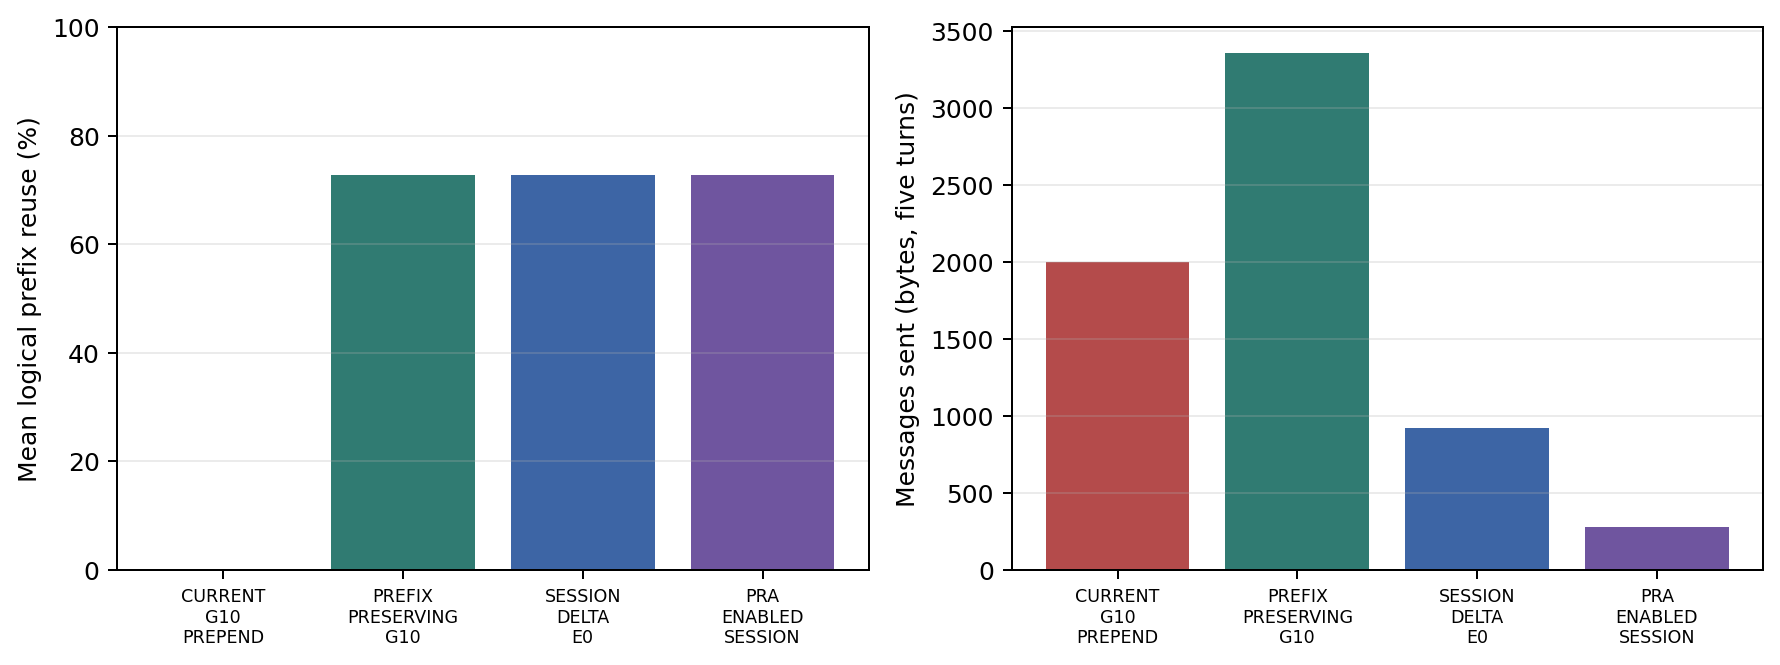

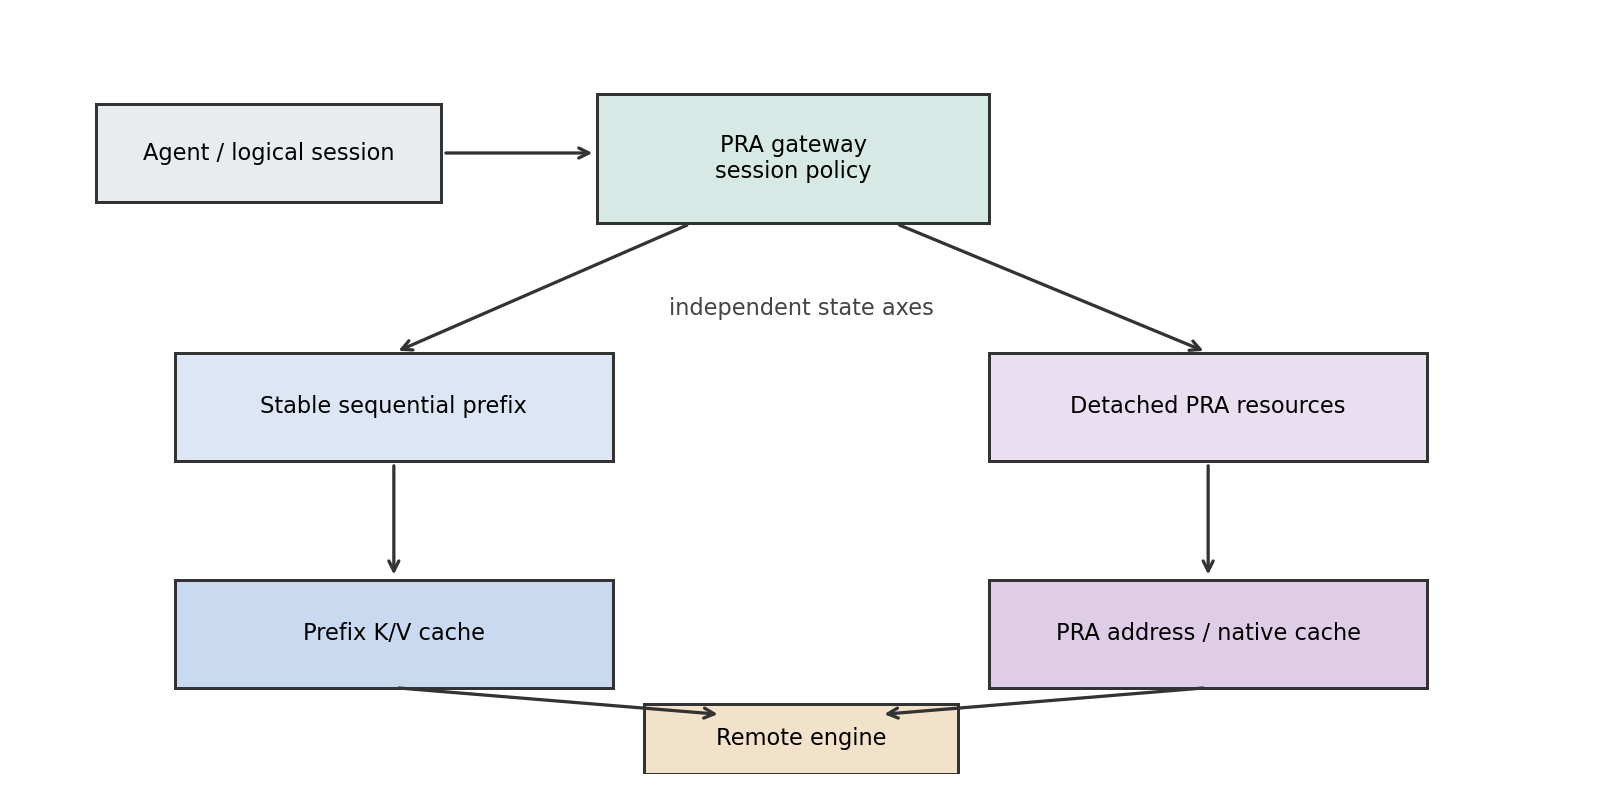

In [35]:
display(Image(filename=str(cross_model_dir / "gateway_prefix_reuse.png")))
display(Image(filename=str(cross_model_dir / "gateway_two_cache_architecture.png")))

## CLI equivalents

The same systems surface is available without notebook state:

```powershell
pra doctor
pra model inspect Qwen/Qwen3-0.6B
pra model adapt Qwen/Qwen3-0.6B -o ./.pra/adapters/qwen3
pra profiles calibrate Qwen/Qwen3-0.6B -s smoke -o ./runtime-results
pra bundle build ./runtime-results -o ./.pra/bundles/qwen3
pra runtime inspect Qwen/Qwen3-0.6B -e hf
pra runtime benchmark Qwen/Qwen3-0.6B -e hf -o ./runtime-results/physical
pra agent chat Qwen/Qwen3-0.6B -w . -t "Inspect the repository"
pra agent run -p work "Summarize the active task"
pra agent start -p work -o
pra gateway serve --mode G10 --backend sglang --backend-url http://localhost:30000
pra gateway serve --mode G10 --backend vllm --backend-url http://localhost:8000 --prefix-cache-mode automatic_prefix_cache
pra gateway serve --mode G11 --backend custom --backend-url http://localhost:9000 --pra-level E1 --session-state --incremental-messages --resource-delta --cache-affinity
```

The product CLI distinguishes architecture integration, learned adapters, profile
calibration, engine launch, agent behavior, and optional Hub publication. `pra-hf`
remains a deprecated alias for one release cycle.

In [36]:
from pra_hf.agent_profiles import AgentProfileRegistry
from pra_hf.runtime_providers import RuntimeConfig, RuntimeManager, RuntimeProviderRegistry

provider_names = RuntimeProviderRegistry.default().names()
hf_runtime = RuntimeManager().inspect(RuntimeConfig(
    engine="hf", model="offline/tiny-llama", profile="REFERENCE_CORRECTNESS"
))
default_agent_profile = AgentProfileRegistry().load().resolve().redacted_dict()
{
    "runtime_providers": provider_names,
    "hf_runtime": hf_runtime,
    "default_agent_profile": default_agent_profile,
}

{'runtime_providers': ('hf', 'mlx', 'openai', 'sglang', 'vllm'),
 'hf_runtime': {'engine': 'hf',
  'engine_version': '4.55.4',
  'launch_mode': 'managed_local',
  'model': 'offline/tiny-llama',
  'revision': None,
  'device': 'auto',
  'pra_bundle': None,
  'pra_profile': 'REFERENCE_CORRECTNESS',
  'endpoint': 'http://127.0.0.1:8000',
  'capabilities': {'adapter': 'hf',
   'engine_type': 'huggingface',
   'integration_level': 'E2',
   'prefix_cache_mode': 'session_state',
   'automatic_prefix_cache': False,
   'explicit_prefix_cache': False,
   'session_state': True,
   'incremental_messages': False,
   'resource_delta': False,
   'cache_affinity': False,
   'prefix_cache_handle': False,
   'logical_refs': True,
   'typed_records': True,
   'task_metadata': True,
   'text_fallback': True,
   'native_kv': True,
   'external_kv_residency': True,
   'cpu_kv': True,
   'pinned_kv': False,
   'gpu_kv': True,
   'semantic_cache': False,
   'streaming': True,
   'selected_interval_materializa

Agent profiles are intentionally separate from `pra.yaml`: runtime configuration controls
model/context execution, while an agent profile controls the endpoint, workspace, sessions,
tool authorization, skill directories, MCP declarations, task policy, and generation budget.
The TUI and experimental FastAPI/WebSocket UI resolve through the same `AgentLauncher` and
durable `SessionService`; credentials remain server-side references.

## What this notebook proves, and what it does not

Demonstrated here:

- one model/memory/resource/execution facade;
- versioned non-secret systems configuration;
- real HF/PRA model wrapping and direct references;
- authenticated cold-to-warm-to-hot external memory;
- exact overlap deduplication and hard materialization budgets;
- native `[B, Hkv, T, D]` storage and parity across four physical layouts;
- eager gather, byte-bounded LRU reuse, stage profiling, and structured benchmarking;
- typed discovery, bounded graph disclosure, and separate execution authorization;
- lazy callable and skill records with exact full-view activation;
- scoped type-aware result compaction, address search, selective replay, and cursors;
- size-adaptive native PRA retrieval, explicit lifecycle state, and lazy selected-region encoding;
- durable user/session resolution, versioned task DAGs, and task-scoped typed records;
- reusable workspace toolsets and a resumable coding-agent terminal UI;
- request/per-layer, token/shared, and first-layer phase/shared execution with
  request-owned traces and a cache-correct probe/prefill handoff;
- a logical gateway request and explicitly labeled text fallback;
- DeepSeek Harness and Pi typed-event bridges over that fallback contract;
- validated task-operation proposals and frozen record-bounded native geometry;
- canonical Paper 3/7/8 materialization profiles and source-relative query rebinding;
- compact prefill/decode native-memory lifetime telemetry;
- tenant-scoped cache identities and per-tenant byte accounting;
- portable HF gateway streaming, cancellation, and request-owned cleanup (covered by tests);
- the canonical product CLI, provider registry, named agent profiles, and bundle boundary;
- a scheduler-unaware vLLM request contract.

Not demonstrated here:

- meaningful language quality from the random tiny model;
- a supported `torch.compile` result on every host;
- Triton/custom CUDA fusion;
- asynchronous transfer overlap or production prefetch;
- continuous batching, p95/p99 serving latency, or a deep vLLM scheduler integration;
- phase/shared routing after a non-first consumer layer;
- Paper-4.5-scale engine performance; companion papers own the measured SGLang and MLX mechanisms;
- native FreeToken, TensorRT-LLM, llama.cpp, TGI, or Ollama adapters.

Those omissions are explicit capability gates, not hidden eager fallbacks.